#**Data with Pandas**



# **Goals of Today**


*   **Chemistry**: How do organize chemical information?
*   **Computation**: Introduction to `Pandas`, a versatile Python package for handling data





#**1. Introduction to Pandas**

We have been using NumPy in our class to generate arrays and work with them. While NumPy is the foundation of much of the SciPy ecosystem and provides very capable ndarray objects, it has a few missing features. The first is that NumPy arrays cannot hold different types of objects in a single array. For example, if we attempt to convert the following list containing integers, floats, and strings into an array, NumPy coverts all elements into strings as a way of making the object types uniform.

In [ ]:
nums = [1, 2, 3, 'four', 5, 'six', 7.0]

In [ ]:
import numpy as np
np.array(nums)

array(['1', '2', '3', 'four', '5', 'six', '7.0'], dtype='<U32')

The second shortcoming is that NumPy arrays do not have strong support for labels in the data. That is, you might want to label rows and column describing what they represent like you might see in a well constructed spreadsheet. While there is some support for this in NumPy, it is not as strong as pandas' support. Finally, while NumPy contains a wealth of basic tools for working with data, there are still many operations that it does not support like grouping data based on the value of a particular column or the ability to merge two data sets with automatic alignment of related data.

To fill in these missing features, the pandas library provides a wealth of additional tools on top of NumPy for working with data, and possibly the most endearing feature, the ability to call data based on labels. That is, data columns and rows can contain human-readable labels that are used to access the data. Pandas still supports accessing data using indices if the user wishes to go that route, but the user can now access data without knowing which column it is in as long as the user knows the column label.
    
By popular convention, the pandas library is imported with the `pd` alias, which is used here. This chapter assumes the following imports.

In [ ]:
import pandas as pd

#**2. Series**

In its simplest form, a `Series` may be created in the same way as a one-dimensional NumPy array.

In [ ]:
mass = pd.Series([1.01,4.00,6.94,9.01,10.81])
mass

,0
0,1.01
1,4.00
2,6.94
3,9.01
4,10.81


The `Series` can be given a name and a data type `dtype`:

In [ ]:
mass = pd.Series([1.01,4.00,6.94,9.01,10.81],
                 name = 'atomic mass of elements',
                dtype=float)
mass

,atomic mass of elements
0,1.01
1,4.00
2,6.94
3,9.01
4,10.81


Unlike a NumPy array, however, each element in a pandas `Series` is associated with an *index*. The right column is the actual data in the Series while the values on the left are the assigned indices for each value in the Series. The index column is not part of the dimensionality of the Series; it is metadata (i.e., data about the data). Think of the numbers as the row labels you would see in a traditional spreadsheet software application. Since we did not set the index explicitly here, a default integer sequence is used for the index:

In [ ]:
mass.index

RangeIndex(start=0, stop=5, step=1)

`RangeIndex` is a pandas object that works in a memory-efficient way like Python's `range` built-in to provide a monotonic integer sequence. However, it is often useful to refer to the rows with some other labels than an integer index. Explicit indexing can be achieved by passing a sequence as the `index` argument.

In [ ]:
index=('H', 'He', 'Li', 'Be', 'B')
mass = pd.Series([1.01,4.00,6.94,9.01,10.81], index=index)
mass

,0
H,1.01
He,4.00
Li,6.94
Be,9.01
B,10.81


The custom indices can now be used to access an element in a Series. This makes a Series behave something like a dictionary.

In [ ]:
mass['He']

4.0

The indices can be accessed by using `mass2.index`. Series indices can also be modified after a Series has been created by using `.index` and assignment as demonstrated below.

In [ ]:
mass.index

Index(['H', 'He', 'Li', 'Be', 'B'], dtype='object')

In [ ]:
mass.index =['H', 'He', 'Li', 'Be', 'B']
mass

,0
H,1.01
He,4.00
Li,6.94
Be,9.01
B,10.81


Even if we create or modify a Series to have custom indices, we can still access the elements using the traditional numerical indices using the `iloc[]` method. This method allows the user to access elements the same way as in a NumPy array regardless of custom index values.

In [ ]:
mass.iloc[2]

6.94

#**3. DataFrame**


Most data you will find yourself working with will be best placed in a two-dimensional pandas object called a *DataFrame* which is always written with two capital letters. The DataFrame is similar to a Series except that now there are also columns with names. The columns can be accessed by column names and rows can be accesses by indices. You might think of a DataFrame as a collection of Series objects. Below, a DataFrame is constructed to hold the names, atomic numbers, masses, and ionization energies of the first five elements.

In [ ]:
name = ['hydrogen', 'helium', 'lithium', 'beryllium','boron']
AN = [1,2,3,4,5]
mass = [1.01,4.00,6.94,9.01,10.81]
IE = [13.6, 24.6, 5.4, 9.3, 8.3]

In [ ]:
columns = ['H', 'He', 'Li', 'Be','B']
index = ['name', 'AN', 'mass', 'IE']
elements = pd.DataFrame([name, AN, mass, IE],
                        columns=columns, index=index)
elements

,H,He,Li,Be,B
name,hydrogen,helium,lithium,beryllium,boron
AN,1,2,3,4,5
mass,1.01,4.0,6.94,9.01,10.81
IE,13.6,24.6,5.4,9.3,8.3


To access data in a DataFrame, place the column name in square brackets.

In [ ]:
elements['Li']

,Li
name,lithium
AN,3
mass,6.94
IE,5.4


Essentially what we get out of a column is a Series with the indices shown on the lefthand side.

To indicate a row, instead use the `loc[]` method. We again get a Series with indices derived from the column names in the source DataFrame. This Series can be placed in a variable and indexed.

In [ ]:
elements.loc['IE']

,IE
H,13.6
He,24.6
Li,5.4
Be,9.3
B,8.3


In [ ]:
atomic_number = elements.loc['AN']

In [ ]:
atomic_number['B']

5

Alternatively, we can use the DataFrame directly and index it with the `loc[]` method as `[row, column]`.

In [ ]:
elements.loc['IE', 'Li']

5.4

Numerical index values can also be used with the `iloc[]` method. This reduces indexing to how NumPy arrays are indexed.

In [ ]:
elements.iloc[2:, 2]

,Li
mass,6.94
IE,5.4


A summary of the methods of indexing pandas Series and DataFrames is presented below in Table 1.

**Table 1** Summary of Pandas Indexing

| Index Method | Description |
|:-----------: | :---------  |
|`s[index]` | Index Series with assigned index values
|`s.iloc[index]` | Index Series with default numerical index values |
|`df[column]` | Index DataFrame with column name|
|`df.loc[row]` | Index DataFrame with row name|
|`df.loc[row, column]` | Index DataFrame with row and column names|
|`df.iloc[row, column]` | Index DataFrame with row and column default numerical index values|


There are several ways one can build a DataFrame.

#**4. Reading/Writing Data**

Similar to NumPy, pandas contains multiple, convenient functions for reading/writing data directly to and from its own object types, and each function is suited to a specific file format. This includes CSV, HTML, JSON, SQL, Excel, and HDF5 files [among others](https://pandas.pydata.org/pandas-docs/stable/user_guide/io.html). We will work with two examples here.

**Table 2** Import/Export Functions in Pandas

| Function | Description |
|:-------: | :---------  |
|`read_csv()` and `to_csv()` | Imports/Exports data from/to a CSV file |
|`read_table()` and `to_table()` | General-purpose importer/exporter |
|`read_hdf5()` and `to_hdf5()` | Imports/Exports data from/to an HDF5 file |
|`read_clipboard()` and `to_clipboard()` | Transfers data to/from the clipboard to a Series or DataFrame |
|`read_excel()` and `to_excel()` | Reads/writes an Excel file|




## 4.1 General-Purpose Delimited File Reader

Before we start with more well-defined file formats, pandas provides a general purpose file reader `pd.read_table()`. This function imports text files where lines represent rows and the data in each row is separated by characters or spaces. The user can designate what character(s) separate the data by using the `delimiter` or `sep` arguments (they do the same thing). To set a space as a delimiter,  use `sep=\s+`. The function also includes a series of other arguments listed below in Table 3.


**Table 3** More `pd.read_table()` Arguments

| Argument | Description |
|:--------:| :-------    |
|`delimiter`| Data separator; default is tab|
|`sep` | Data separator; default is tab|
|`skiprows` | Number of rows at the top of the file to skip before reading data|
|`skipfooter` | Number of rows at the bottom of the file to skip|
|`skip_blank_lines`| If `True`, skips blank lines in file; default is `False`|
|`header` | Row number to use for a data header; also accepts None if no header is provided in the file|
|`skipinitialspace` | If `True`, skips white space after delimiter|

As an example, we can use this function to read an XYZ file of benzene and extract the $xyz$ coordinates for each atom. All the data columns here have spaces between them, we can use space delimitation by setting  `sep=\s+`. Because the data do not start until the third line, we should exclude these rows. We set `header=None` because we do not want the function to treat the first line of data as a header or data label.





Let us download an xyz file and work from here.

In [ ]:
!wget https://raw.githubusercontent.com/nutjunkie/IQmol/master/share/fragments/Molecules/Aromatics/Benzene.xyz

--2025-03-04 22:32:16--  https://raw.githubusercontent.com/nutjunkie/IQmol/master/share/fragments/Molecules/Aromatics/Benzene.xyz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 491 [text/plain]
Saving to: ‘Benzene.xyz.1’

Benzene.xyz.1       100%[===================>]     491  --.-KB/s    in 0s      

2025-03-04 22:32:16 (32.5 MB/s) - ‘Benzene.xyz.1’ saved [491/491]



In [ ]:
!cat Benzene.xyz

12
Benzene
  H      1.2194     -0.1652      2.1600
  C      0.6825     -0.0924      1.2087
  C     -0.7075     -0.0352      1.1973
  H     -1.2644     -0.0630      2.1393
  C     -1.3898      0.0572     -0.0114
  H     -2.4836      0.1021     -0.0204
  C     -0.6824      0.0925     -1.2088
  H     -1.2194      0.1652     -2.1599
  C      0.7075      0.0352     -1.1973
  H      1.2641      0.0628     -2.1395
  C      1.3899     -0.0572      0.0114
  H      2.4836     -0.1022      0.0205


In [ ]:
benz = pd.read_table('Benzene.xyz', sep='\s+',
                     skiprows=2, skipfooter=0, header=None,
                     engine='python')
benz

,0,1,2,3
0,H,1.2194,-0.1652,2.1600
1,C,0.6825,-0.0924,1.2087
2,C,-0.7075,-0.0352,1.1973
3,H,-1.2644,-0.0630,2.1393
4,C,-1.3898,0.0572,-0.0114
5,H,-2.4836,0.1021,-0.0204
6,C,-0.6824,0.0925,-1.2088
7,H,-1.2194,0.1652,-2.1599
8,C,0.7075,0.0352,-1.1973
9,H,1.2641,0.0628,-2.1395


##**4.2 Comma Separated Values Files**

Pandas provides a collection of more format-specific functions for reading/writing files. The most popular is possibly the CSV file because it is simple and many scientific instruments support exporting data in this format. To import a CSV file, we will use the `read_csv()` function. This function is very similar to the `read_table()` function except that a default value for the separator/delimiter is set to a comma. To create a CSV file, use the `to_csv()` method which at a minimum requires the file name and a pandas object with the data.

We can write the above chemical element data assembled in [section 5.1](5.1) as shown below. Because we are starting from a pandas object and are using a pandas method, the `df.to_csv()` format is used where df is a DataFrame.

~~~python
elements.to_csv('elements.csv')
~~~

If we check the directory containing the Jupyter notebook, the data folder contains a file titled *elements.csv* that looks like the following. Each row in the DataFrame is a different line in the file, and every column is separated by a comma.

    H,He,Li,Be,B
    name,hydrogen,helium,lithium,berylium,boron
    AN,1,2,3,4,5
    mass,1.01,4.0,6.94,9.01,10.81
    IE,13.6,24.6,5.4,9.3,8.3

To read the data back in from the file, use `pd.read_csv()`. Because we are not starting with a pandas object, the function is called using the `pd.function()` format.

In [ ]:
# write the csv file
elements.to_csv('elements.csv')

In [ ]:
# now read the csv file
pd.read_csv('elements.csv')

,H,He,Li,Be,B
name,hydrogen,helium,lithium,berylium,boron
AN,1,2,3,4,5
mass,1.01,4.0,6.94,9.01,10.81
IE,13.6,24.6,5.4,9.3,8.3



#**5.Examining Data with Pandas**

Once you load data into pandas, you will likely want to get an idea of what the data look like before you proceed to calculations and in-depth analyses. This section covers a few methods provided in pandas to gain a preliminary understanding of your data.




## **5.1 Descriptive Functions**


`Pandas` provides a few simple functions to view and describe new data. The first two are `head()` and `tail()` which allow you to see the top and bottom of the DataFrame, respectively. These are particularly useful when dealing with very large DataFrames. Below, a DataFrame containing random values in an even, normal, and poisson distribution ($\lambda$ = 3.0) demonstrates these functions.

In [ ]:
rng = np.random.default_rng()

In [ ]:
# hidden cell
rng = np.random.default_rng(seed=18)

In [ ]:
random = pd.DataFrame({'even': rng.random(1000),
                       'normal': rng.normal(size=1000),
                       'poisson': rng.poisson(lam=3.0, size=1000)})

In [ ]:
random.head()

,even,normal,poisson
0,0.399306,0.366845,3
1,0.717415,0.240555,3
2,0.280823,-1.014316,4
3,0.082725,-0.249080,3
4,0.969771,0.414425,3


In [ ]:
random.tail()

,even,normal,poisson
995,0.068204,-0.628008,3
996,0.618927,0.232807,1
997,0.103016,0.182341,5
998,0.483815,1.177764,4
999,0.750867,-0.837742,2


Pandas also contains a `describe()` function that returns a variety of statistics on each column. For example, the mean is provided which are approximately 0.5, 0.0, and 3.0 for the even, normal, and poisson distributions, respectively. This is not surprising being that the even distribution is centered around 0.5, the normal around 0.0, and the poisson distribution is generated for an average of 3.0. The user is also provided with the minimum, maximum, standard deviation, and the quartile boundaries.

In [ ]:
random.describe()

,even,normal,poisson
count,1000.000000,1000.000000,1000.000000
mean,0.495366,0.009895,2.965000
std,0.293186,1.000833,1.688972
min,0.000812,-3.324801,0.000000
25%,0.230925,-0.657265,2.000000
50%,0.505785,0.003473,3.000000
75%,0.742341,0.651874,4.000000
max,0.999107,3.143804,10.000000


Another useful function is the `value_counts()` method which returns all unique values in a Series (or DataFrame column or row). Below, it is demonstrated on the poisson column being that the other two columns will have a relatively large number of unique values.

In [ ]:
counts = random['poisson'].value_counts()
counts

,count
poisson,
3,235
2,224
4,188
1,155
5,74
6,52
0,43
7,18
8,5


Data in DataFrames can be plotting by calling the desired columns of data and feeding them into plotting functions like `plt.scatter()`. The data can also be visualized by using the `df.plot(kind=)` format where `df` is the DataFrame and `kind` is the plot type (e.g., `'bar'`, `'hist'`, `'scatter'`, `'line'`, `'pie'`, etc...). However, this is just matplotlib doing the plotting and is largely redundant with other methods already covered. Below is a quick example of the counts data generated above.

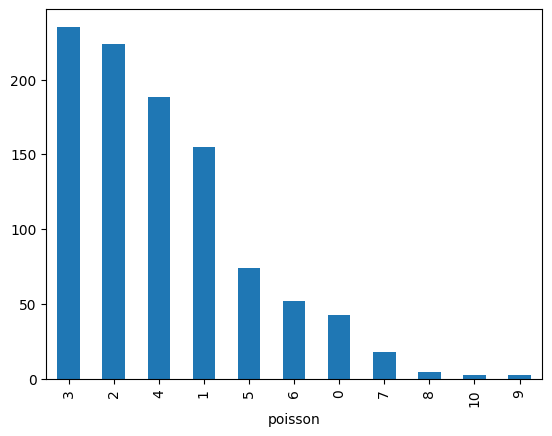

In [ ]:
counts.plot(kind='bar');

## **5.2 Broadcasted Mathematical Operations**

Because pandas is built upon NumPy arrays, mathematical operations are propagated through Series and DataFrames. The user is able to use NumPy methods on pandas objects, and there are a number of other mathematical operations to chose from such as those listed below.

**Table 4** Broadcasted Pandas Methods

| Function | Description |
|:-------: | :---------  |
|`abs()` | Absolute value |
|`count()` | Counts items |
|`cumsum()` | Cumulative sum |
|`cumprod()` | Cumulative product |
|`mad()` | Mean absolute deviation |
|`max()` | Maximum |
|`min()` | Minimum |
|`mean()` | Mean |
|`median()` | Median |
|`mode()` | Mode |
|`std()` | Standard deviation|



#**6 Modifying DataFrames**

Now that you are able to generate DataFrames, it is useful to be able to modify them as you clean your data or perform calculations. This can be done through methods such as assignment, dropping rows and columns, and combining DataFrames or Series.



## 6.1 Insert Columns via Assignment


Possibly the easiest method of adding a new column is through assignment. If a nonexistent column is called and assigned values, instead of returning an error, pandas creates a new column with the given name and populates it with the data. For example, the `elements` DataFrame below does not contain a carbon column, so the column is added when assigned to a Series with the data.

In [ ]:
elements

,H,He,Li,Be,B
name,hydrogen,helium,lithium,beryllium,boron
AN,1,2,3,4,5
mass,1.01,4.0,6.94,9.01,10.81
IE,13.6,24.6,5.4,9.3,8.3


In [ ]:
elements['C'] = ['carbon', 6, 12.01, 11.3]
elements

,H,He,Li,Be,B,C
name,hydrogen,helium,lithium,beryllium,boron,carbon
AN,1,2,3,4,5,6
mass,1.01,4.0,6.94,9.01,10.81,12.01
IE,13.6,24.6,5.4,9.3,8.3,11.3


## 6.2 Automatic Alignment

Another important feature of pandas is the ability to automatically align data based on labels. In the above example, carbon is added to the DataFrame with the name, atomic number, atomic mass, and ionization energy in the same order as in the DataFrame. What happens if the new data is not in the correct order? If we are using NumPy, this would require additional effort on the part of the user to reorder the data. However, if each value is labeled, pandas will see to it that they are placed in the correct location.

In [ ]:
nitrogen = pd.Series([7, 14.01, 'nitrogen', 14.5],
                     index=['AN', 'mass', 'name', 'IE'])
nitrogen

,0
AN,7
mass,14.01
name,nitrogen
IE,14.5


Data for nitrogen is placed in a Series above. Notice that the values are out of order with respect to the data in `elements`. There are index labels (i.e., row labels) that tell pandas what each piece of data is, and pandas will use them to determine where to place the new information.

In [ ]:
elements['N'] = nitrogen
elements

,H,He,Li,Be,B,C,N
name,hydrogen,helium,lithium,beryllium,boron,carbon,nitrogen
AN,1,2,3,4,5,6,7
mass,1.01,4.0,6.94,9.01,10.81,12.01,14.01
IE,13.6,24.6,5.4,9.3,8.3,11.3,14.5


The new column of nitrogen data has been added to `elements` with all pieces of data residing in the correct row.

## 6.3 Dropping Columns


When cleaning up data, you may wish to drop a column or row. Pandas provides the `drop()` method for this purpose. It requires the name of the column or row to be dropped, and by default, it assumes a row, `axis=0`, is to be dropped. If you want to drop a column, change the axis using the `axis=1` argument. Below, the hydrogen column is dropped from the elements DataFrame.

In [ ]:
elements.drop('H', axis=1)

,He,Li,Be,B,C,N
name,helium,lithium,beryllium,boron,carbon,nitrogen
AN,2,3,4,5,6,7
mass,4.0,6.94,9.01,10.81,12.01,14.01
IE,24.6,5.4,9.3,8.3,11.3,14.5


In [ ]:
elements.drop('IE', axis=0)

,H,He,Li,Be,B,C,N
name,hydrogen,helium,lithium,beryllium,boron,carbon,nitrogen
AN,1,2,3,4,5,6,7
mass,1.01,4.0,6.94,9.01,10.81,12.01,14.01


In the second example above, the hydrogen is back despite being previously dropped. This is because the `drop()` method does not by default modify the origional DataFrame. To make the changes perminent, either assigned the new DataFrame to a new variable or add the `inplace=True` keyword argument to the above `drop()` function.

```{index} single: missing values; with pandas
```

There is a similar function `pd.dropna()` that drops columns or rows from a DataFrame that contain `nan` values. This is commonly used to remove incomplete data from a data set. The `pd.dropna()` function behaves very similarily to the `pd.drop()` function including the `inplace=` and `axis=` arguments.

## 6.4 Merge

To merge multiple DataFrames, pandas provides a `merge()` method. Similar to above, the `merge()` function will properly align data, but because DataFrames have multiple columns and index values to choose from, the `merge()` function can align data based on any of these values. The default behavior for `merge()` is to check for common columns between the two DataFrames and align the data based on those columns. As an example, below are two DataFrames containing data from various chemical compounds.

In [ ]:
chemdata1 = [['MW', 58.08, 32.04], ['dipole', 2.91, 1.69],
             ['formula', 'C3H6O', 'CH3OH']]
columns=['property','acetone', 'methanol']
chmdf1 = pd.DataFrame(chemdata1, columns=columns)

In [ ]:
chmdf1

,property,acetone,methanol
0,MW,58.08,32.04
1,dipole,2.91,1.69
2,formula,C3H6O,CH3OH


In [ ]:
chmdata2 = [['formula', 'C6H6', 'H2O'], ['dipole', 0.00, 1.85],
            ['MW', 78.11, 18.02]]
chmdf2 = pd.DataFrame(chmdata2 , columns=['property', 'benzene', 'water'])

In [ ]:
chmdf2

,property,benzene,water
0,formula,C6H6,H2O
1,dipole,0.0,1.85
2,MW,78.11,18.02


Both DataFrames above have a `property` column, so the `merge()` function uses this common column to align all the data into a new DataFrame.

In [ ]:
chmdf1.merge(chmdf2)

,property,acetone,methanol,benzene,water
0,MW,58.08,32.04,78.11,18.02
1,dipole,2.91,1.69,0.0,1.85
2,formula,C3H6O,CH3OH,C6H6,H2O


If there are multiple columns with the same name, the user can specify which to use with the `on` keyword argument (e.g., `on='property'`). Alternatively, if the two DataFrames contain columns with different names that the user wants used for alignment, the user can specify which columns to use with the `left_on` and `right_on` keyword arguments.

In [ ]:
comps1 = pd.DataFrame({'element':['Co', 'Fe', 'Cr','Ni'],
                       'protons': [27, 26, 24, 28]})
comps2 = pd.DataFrame({'metal':['Fe', 'Co', 'Cr', 'Ni'],
                       'IE': [7.90, 7.88, 6.79, 7.64]})

In the two DataFrames generated above, each contains data on on cobalt, iron, chromium, and nickel; but the first DataFrame labels metals as `element` while the second labels the metals as `metal`. The following merges the two DataFrames based on values in these two columns.

In [ ]:
comps1.merge(comps2, left_on='element',right_on='metal')

,element,protons,metal,IE
0,Co,27,Co,7.88
1,Fe,26,Fe,7.90
2,Cr,24,Cr,6.79
3,Ni,28,Ni,7.64


Notice that the values in the `element` and `metal` columns were aligned in the resulting DataFrame. To get rid of one of the redundant columns, just use the `drop()` method described in [section 5.4.3](5.4.3).

In [ ]:
comps3 = comps1.merge(comps2, left_on='element',
                      right_on='metal')
comps3.drop('metal', axis=1, inplace=True)
comps3

,element,protons,IE
0,Co,27,7.88
1,Fe,26,7.90
2,Cr,24,6.79
3,Ni,28,7.64


## 6.5 Concatenation

Concatenation is the process of splicing two DataFrames along a given axis. This is different from the `merge()` method above in that `merge()` merges and aligns common data between the two DataFrames while `pd.concat()` blindly appends one DataFrame to another. As an example, imagine two lab groups measure the densities of magnesium, aluminum, titanium, and iron and load their results into DataFrames below.

In [ ]:
group1 = pd.DataFrame({'metal':['Mg', 'Al', 'Ti', 'Fe'],
                       'density': [1.77, 2.73, 4.55, 7.88]})
group2 = pd.DataFrame({'metal':['Al', 'Mg', 'Ti', 'Fe'],
                       'density': [2.90, 1.54, 4.12, 8.10]})

In [ ]:
group1

,metal,density
0,Mg,1.77
1,Al,2.73
2,Ti,4.55
3,Fe,7.88


See what happens when these two DataFrames are concatenated.

In [ ]:
pd.concat((group1, group2))

,metal,density
0,Mg,1.77
1,Al,2.73
2,Ti,4.55
3,Fe,7.88
0,Al,2.90
1,Mg,1.54
2,Ti,4.12
3,Fe,8.10


Notice how the two DataFrames are appended with no consideration for common values in the `metal` column. The default behavior is to concatenate along the first axis (`axis=0`), but this behavior can be modified with the `axis=` keyword argument. Again, the metals are not all aligned below because they were not in the same order in the original DataFrames.

In [ ]:
pd.concat((group1, group2), axis=1)

,metal,density,metal,density
0,Mg,1.77,Al,2.90
1,Al,2.73,Mg,1.54
2,Ti,4.55,Ti,4.12
3,Fe,7.88,Fe,8.10


For comparison, if the two DataFrames are merged instead of concatenating them, pandas will align the data based on the `metal` as demonstrated below. Because `density` appears twice as a column header, pandas deals with this by adding a suffix to differentiate between the two data sets.

In [ ]:
pd.merge(group1, group2, on='metal')

,metal,density_x,density_y
0,Mg,1.77,1.54
1,Al,2.73,2.90
2,Ti,4.55,4.12
3,Fe,7.88,8.10


# **Further Reading**

This set of note is largely based on the tutorial available in [Scientific Computing for Chemists with Python](https://weisscharlesj.github.io/SciCompforChemists/notebooks/introduction/intro.html), where a lot more resources can be found. For further resources on the pandas library, see the following. The value of the pandas website cannot be emphasized enough as it contains a large quantity of high quality documentation and illustrative examples on using pandas for data analysis and processing.

1. Pandas Website. [http://pandas.pydata.org/](http://pandas.pydata.org/) (free resource)

2. VanderPlas, J. Python data Science Handbook: Essential Tools for Working with Data, 1st ed.; O’Reilly: Sebastopol, CA, 2017, chapter 3. Freely available from the author at [https://jakevdp.github.io/PythonDataScienceHandbook/](https://jakevdp.github.io/PythonDataScienceHandbook/) (free resource)

3. McKinney, W. Python for Data Analysis: Data Wrangling with Pandas, NumPy, and Ipython, 2nd ed.; O’Reilly: Sebastopol, CA, 2018.

#**In-class exercise**


Below is a table containing the melting points and boiling points of multiple common chemical solvents.

|  Solvent  |  bp  |  mp  |
|  :------: | :--: | :--: |
| benzene  | 80 | 6 |
| acetone | 56 | -95 |
| toluene | 111 | -95 |
| pentane |  36 | -130 |
| ether | 35 | -116 |
| ethanol | 78 | -114 |
| methanol | 65 | -98 |


    

    


   a) Create a Series containing the boiling points of the above solvents with the solvent names as the indices. Call the Series to look up the boiling point of ethanol.
    
  
      
   

In [ ]:
# [Code here]

  b) Create a DataFrame that contains both the boiling points and melting points with the solvent names as the indices. Call the DataFrame to look up the melting point of benzene.

In [ ]:
# [Code here]

 c) Access the boiling point of pentane in the DataFrame from part b using numerical indices.

In [ ]:
# [Code here]

d) Work with other capabilities on the DataFrame that you have learned today.

In [ ]:
# [Code here]

# **Debrief: What have we learned today?**

Let us reflect on what are the new skills we have learned today. We will classify the skills into chemical knowledge and computation skills.

**New chemical knowledge today:**

*   List response
*   List response

**New computational skill today:**

*   List response


## **How can I make the class better?**

Please let me know [here](https://docs.google.com/forms/d/e/1FAIpQLSd6iRTXWhMHmc0MqXXiAWdglDqEa0mKcXQRXm6LyD4HS-6v7g/viewform)!